In [2]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from natsort import natsorted

# Jupyter CWD is the notebook's folder (Analysis/), so ".." is the project root
sys.path.insert(0, str(Path().resolve().parent))
# Path() means the current working directory
# resolve() make it absolute but there is no parameter in Path(), so it's actually adundant
# sys.path is a list, python would search this list once it's going to import a module

from Condition_model import cond_sampler, dataset, forecasting, utils
from Condition_model.dataset import SQGDataset, DATA_PATH, DATA_500

# 0. Check the sanity of invert data

Visualize the invert data to examine whether it is noise like data.

In [12]:
import re

# invert_data_path = Path(__file__).resolve().parent.parent / 'data' / 'invert'
# # this can be used in .py file
# invert_data_path = Path(__file__).resolve().parent.parent / 'data' / 'invert'
# # there is no __file__ variable in jupyter, so you can use this instead
invert_data_path = DATA_PATH / 'invert_steps=300'

# but we actually have defined DATA_PATH in dataset.py
# print(invert_data_path)
invert_files_name = natsorted(invert_data_path.glob('*.npy'))
true_dataset = SQGDataset(DATA_500)

std = 2660
invert_data = []
true_data = []
# use regular expressions to identify the traj_idx and anchor_idx
for f in invert_files_name:
    invert = np.load(f) / std
    match = re.search(r"invert_traj(\d+)initial(\d+).npy", str(f))
    assert match is not None, f"Filename {f} does not match the expected pattern"

    traj_idx = int(match.group(1))
    anchor_idx = int(match.group(2))
    
    true_data.append(true_dataset[traj_idx][anchor_idx:anchor_idx+24])
    invert_data.append(invert)
    
# I want visualize the comparison using .gif
# and I also want to encapulate the code into a function



In [13]:
import matplotlib.animation as animation
from IPython.display import HTML

def compare_gif(invert, true, idx=0, channel=0, fps=4):
    """
    Animate one sample from invert_files and true_data side by side.

    Args:
        invert  : list of arrays, each (T, C, H, W)
        true    : list of arrays, each (T, C, H, W)
        idx     : which sample to visualise
        channel : which channel to show (0 or 1)
        fps     : frames per second
    """
    inv = invert[idx][:, channel]   # (T, H, W)
    tru = true[idx][:, channel]     # (T, H, W)
    T   = inv.shape[0]

    vmin = min(inv.min(), tru.min())
    vmax = max(inv.max(), tru.max())

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].set_title(f"Invert  (idx={idx}, ch={channel})")
    axes[1].set_title(f"True    (idx={idx}, ch={channel})")
    for ax in axes:
        ax.axis("off")

    im0 = axes[0].imshow(inv[0], vmin=vmin, vmax=vmax, cmap="RdBu_r", animated=True)
    im1 = axes[1].imshow(tru[0], vmin=vmin, vmax=vmax, cmap="RdBu_r", animated=True)
    fig.colorbar(im0, ax=axes, fraction=0.046, pad=0.04)
    step_txt = fig.text(0.5, 0.02, "t=0", ha="center", fontsize=10)

    def update(t):
        im0.set_data(inv[t])
        im1.set_data(tru[t])
        step_txt.set_text(f"t={t}")
        return im0, im1, step_txt

    ani = animation.FuncAnimation(fig, update, frames=T, interval=1000 // fps, blit=True)
    plt.close(fig)
    return HTML(ani.to_jshtml())

compare_gif(invert_data, true_data, idx=2, channel=0)

# Examine Gaussianity

# 1. correlation structure of the inverted latents

Per-lead marginals of $z_\tau$ carry **zero** information about the noise correlation (CEWF §4.2: all correlation choices give identical per-lead marginals). The information lives in the **joint/temporal** statistics, and the inverted latents $z_\tau = \Phi^{-1}_{x_0,\tau}(x_\tau)$ of real trajectories are exactly the sufficient object: "what noise process would the true dynamics have required?"

**Plan (from Analysis doc):**
- **Step 0 — marginal check** (validity precondition): $z_\tau \sim \mathcal N(0, I)$ per lead — moments, kurtosis, cross-channel correlation, QQ, and spatial spectrum flatness. Departures = model error dumped into the latents by the inversion; *where* the spectrum departs from flat = spatial scales where the drift is wrong.
- **Step 1 — empirical correlation** $\hat\rho(\tau,\tau') = \frac{1}{d}\mathbb E[\langle z_\tau, z_{\tau'}\rangle]$, $d = 2\cdot64\cdot64 = 8192$. Inner products concentrate at this dimension (per-sample fluctuation $\sim d^{-1/2} \approx 0.011$), so ~400 inversions give SE $\approx 6\times10^{-4}$ — cheap and statistically strong.
- **Step 2 — test Thread-3 hypotheses**: (a) stationarity: does $\hat\rho$ depend only on $\Delta=|\tau-\tau'|$? (b) exponential decay: OU/AR(1) predicts $\log\hat\rho$ linear in $\Delta$ — if linear, read the rate off the slope and Thread 3's first milestone falls out with no learning machinery; if not, a smoother kernel (e.g. squared-exponential) is required. (c) $x_0$-dependence: bin $\hat\rho$ by anchor enstrophy — dependence ⟹ the conditional-noise-model question is real.
- **Step 3 — identifiability control**: invert the α=0.5 forecasts (known within-window correlation $\rho(\Delta)=0.5^{\Delta/2}$, since `get_latents` is AR(1) with coefficient $\sqrt\alpha$) and check the invert→estimate pipeline recovers the known rate. **Run before trusting Steps 1–2.**

**⚠ Units.** The cells below rebuild the arrays instead of reusing `invert_data` / `true_data` from above, because of three unit traps (existing cells left untouched):
1. The saved invert latents are **already normalised** (`SQGLeadTimeDataset` divides by std=2660 before inversion) — dividing by 2660 again makes them ~4e-4: harmless for imshow, fatal for testing $z\sim\mathcal N(0,I)$.
2. `SQGDataset.__getitem__` divides by std a **second** time (once in `__init__`, once in `__getitem__`) — `true_dataset[i]` is double-normalised; `true_dataset.data[i]` is the single-normalised model-unit field.
3. Eval targets are leads 1…24 (`forecasting_leads[1:]`), so `z[k]` pairs with frame `anchor+1+k` — the slice `[anchor : anchor+24]` above is off by one; the anchor itself is frame `anchor_t`.

In [14]:
%matplotlib inline
# ^ train.py calls matplotlib.use('Agg') at import time (and cell 1 imports it via
#   forecasting) — switch back so figures actually render in the notebook.
import re
from scipy import stats

# ── Data preparation (correct units, see markdown above) ────────────────────
# Z       : inverted latents, RAW from file — already in normalised model units
# anchors : anchor frame x_0 per sample, single-normalised (true_dataset.data,
#           NOT true_dataset[i] which divides by std twice)
Z = np.stack([np.load(f).astype(np.float32) for f in invert_files_name])   # (N, 24, 2, 64, 64)

meta = np.array([
    [int(m.group(1)), int(m.group(2))]
    for f in invert_files_name
    for m in [re.search(r"invert_traj(\d+)initial(\d+).npy", str(f))]
])                                                                          # (N, 2) = [traj_idx, anchor_t]
anchors = np.stack([true_dataset.data[tj][at] for tj, at in meta])          # (N, 2, 64, 64)

N, L, C, H, W = Z.shape
d = C * H * W                       # dimension of one latent field = 8192
leads = np.arange(1, L + 1)         # z[k] corresponds to lead τ = k+1 hours

print(f"Z       : {Z.shape}   global mean = {Z.mean():+.4f}, std = {Z.std():.4f}  (0, 1 expected)")
print(f"anchors : {anchors.shape}          std = {anchors.std():.4f}  (≈1 expected in model units)")

Z       : (100, 24, 2, 64, 64)   global mean = -0.0044, std = 0.9666  (0, 1 expected)
anchors : (100, 2, 64, 64)          std = 0.9918  (≈1 expected in model units)


## Step 0 — marginal check: $z_\tau \sim \mathcal N(0, I)$ per lead

Validity precondition, not optional: inversion of *data* under an imperfect drift dumps model error into the latents, and non-Gaussian marginals contaminate every correlation estimate downstream. 

Checks: 

(i) per-lead mean / std / **excess kurtosis** and cross-channel correlation (identity covariance ⟹ channels independent), 

(ii) QQ plots



**Question:** But why per-lead Gaussianity check specifically?

The reason this specific marginal matters: the inversion $z_\tau = \Phi^{-1}_{x_0, \tau}(x_\tau)$
 is a separate map for each lead. The model was trained with lead-time conditioning, so the latent at $\tau=6$ and the latent at $\tau=24$ come from different effective mappings. There's no reason to expect them to have identical distributions. Per-lead kurtosis gives you one value per $\tau$, so you can see whether the Gaussian assumption holds differently at different lead times

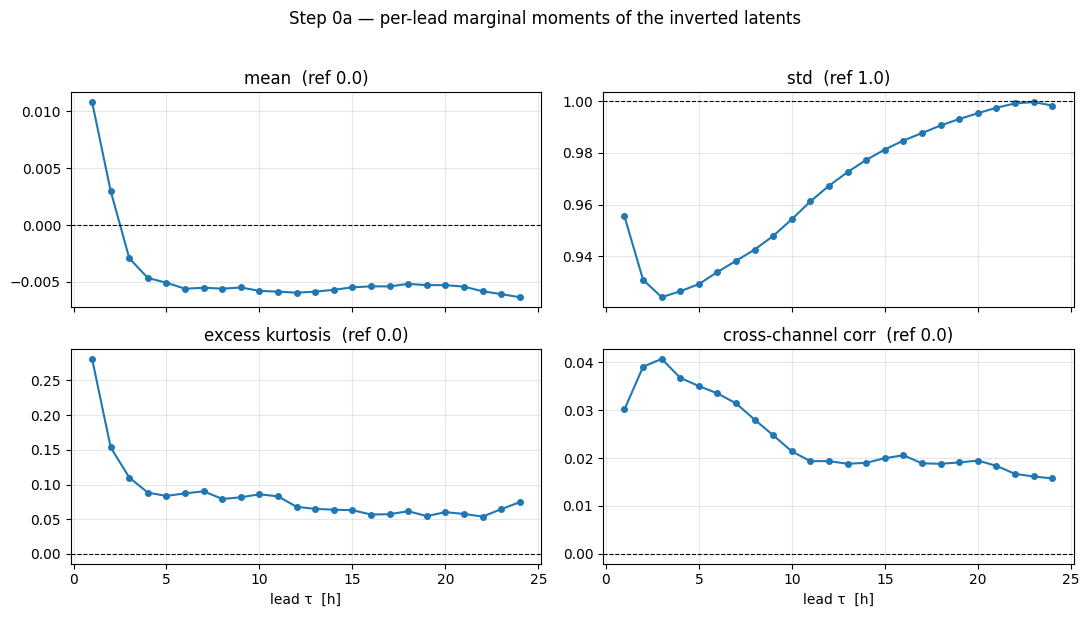

worst |mean|      : 0.0108  at lead 1
std range         : [0.9241, 0.9997]
worst |kurtosis|  : 0.2808  at lead 1
worst |xchan corr|: 0.0407  at lead 3


In [15]:
# ── Step 0a: per-lead moments and cross-channel correlation ─────────────────
# Z (387, 24, 2, 64, 64)
# Zl (24, 387, 2, 64, 64) -> (24, 387*2*64*64)
# pooled over lead-time
Zl = Z.transpose(1, 0, 2, 3, 4).reshape(L, -1)        # (L, N·C·H·W) — lead-major

# n_pixels = Zl.shape[-1]
mean_l = Zl.mean(axis=1)
std_l  = Zl.std(axis=1)
# it is computed over trajectory level
kurt_l = stats.kurtosis(Zl, axis=1)                   # excess kurtosis (0 for Gaussian)

# cross-channel correlation per lead: N(0, I) ⟹ the two levels are independent
z0 = Z[:, :, 0].reshape(N, L, -1) - Z[:, :, 0].reshape(N, L, -1).mean(axis=(0, 2), keepdims=True)
z1 = Z[:, :, 1].reshape(N, L, -1) - Z[:, :, 1].reshape(N, L, -1).mean(axis=(0, 2), keepdims=True)
xchan_l = (z0 * z1).mean(axis=(0, 2)) / (z0.std(axis=(0, 2)) * z1.std(axis=(0, 2)))

# I also want to know whether the results are significant

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
panels = [
    (mean_l,  0.0, "mean",                axes[0, 0]),
    (std_l,   1.0, "std",                 axes[0, 1]),
    (kurt_l,  0.0, "excess kurtosis",     axes[1, 0]),
    (xchan_l, 0.0, "cross-channel corr",  axes[1, 1]),
]
for vals, ref, name, ax in panels:
    ax.plot(leads, vals, "o-", ms=4)
    ax.axhline(ref, color="k", lw=0.8, ls="--")
    ax.set_title(f"{name}  (ref {ref})")
    ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("lead τ  [h]")
fig.suptitle("Step 0a — per-lead marginal moments of the inverted latents", y=1.02)
fig.tight_layout()
plt.show()

print(f"worst |mean|      : {np.abs(mean_l).max():.4f}  at lead {leads[np.abs(mean_l).argmax()]}")
print(f"std range         : [{std_l.min():.4f}, {std_l.max():.4f}]")
print(f"worst |kurtosis|  : {np.abs(kurt_l).max():.4f}  at lead {leads[np.abs(kurt_l).argmax()]}")
print(f"worst |xchan corr|: {np.abs(xchan_l).max():.4f}  at lead {leads[np.abs(xchan_l).argmax()]}")

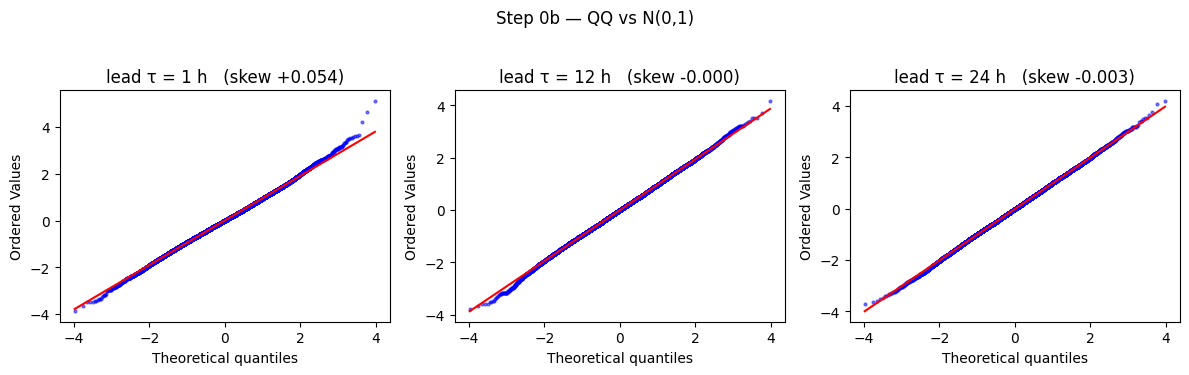

In [16]:
# ── Step 0b: QQ plots against N(0,1) for a few leads ────────────────────────
rng = np.random.default_rng(0)
qq_leads = [1, 12, 24]

fig, axes = plt.subplots(1, len(qq_leads), figsize=(12, 3.6))
for ax, tau in zip(axes, qq_leads):
    vals = Zl[tau - 1]
    sub  = vals[rng.choice(vals.size, size=20_000, replace=False)]   # subsample for speed
    stats.probplot(sub, dist="norm", plot=ax)
    ax.set_title(f"lead τ = {tau} h   (skew {stats.skew(sub):+.3f})")
    ax.get_lines()[0].set(ms=2, alpha=0.5)
fig.suptitle("Step 0b — QQ vs N(0,1)", y=1.03)
fig.tight_layout()
plt.show()

(iii) **radially averaged spatial power spectrum** — white noise ⟹ flat spectrum, and where it departs from flat tells us at which spatial scales the drift is wrong (a free diagnostic).

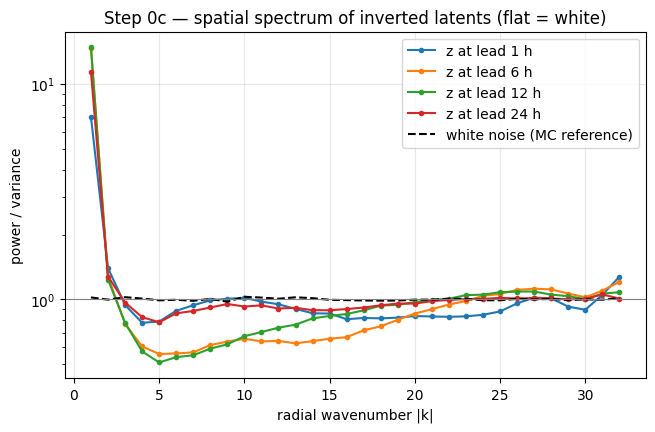

lead 1: power ratio at k=1..3 : 3.116   (>1 ⟹ excess large-scale energy)
lead 1: power ratio at k≥28   : 1.031   (<1 ⟹ missing small-scale energy)


In [17]:
# ── Step 0c: spatial power spectrum flatness ────────────────────────────────
# White noise ⟹ flat radially-averaged 2-D spectrum. Each spectrum is divided
# by the field variance, so 'flat at 1.0' is the null — the test is about SHAPE.
# Departures localise the spatial scales where the drift is wrong.

def radial_power_spectrum(fields):
    """
    fields: (..., H, W) → (n_bins,) radially averaged power spectrum, averaged
    over all leading axes, normalised by the field variance (white noise ⟹ ≈1).
    """

    # fields (num_traj, C, H, W)

    # It doesn't say computation of average in which axis
    # Reason: k=0 Fourier component represents the mean value of the field
    # If the field has a nonzero mean, the DC component dominates the spectrum and obscrues everything else
    f = fields - fields.mean()

    # decompose field into frequencies
    # use Pareval's theorem to transform the frequencies into powers
    # normalize by dividing H*W so that the sum of all frequency powers equal to f.var()

    # So if every pixel in the origin field is i.i.d N(0, 1), the expected power at every frequency is exactly 1
    # fft2 would preserve all shapes
    # here fft performs on each field, that's why axes are the last 2
    P = np.abs(np.fft.fft2(f, axes=(-2, -1))) ** 2 / (H * W)   

    # As above, E(P_k) = var(f) since the field has substracted the dift
    # so each power has expected value var(f) for white noise

    # dividing f.var() is the normalisation
    # after normalisation, the relative deviation of field distribution from normal distribution would be shown
    # but in Cartesian coordinates
    
    # mean is pooling: it would return the average power over all trajectories and channels
    P = P.reshape(-1, H, W).mean(axis=0) / f.var()

    # It's the regular process to calculate the radical power for 2D field
    # the reason why it needs radical spectrum is that it is regardless of direction

    # each point (k_x, k_y) in the 2D frequency grid is assigned a radial wavenumber k_r = (k_x^2, k_y^2)^0.5
    # This is the distance from the origin in frequency space 

    # After fft2, the output is indexed 0 to H−1 and 0 to W−1
    # But index 0 is not frequency 0, index 1 is not frequency 1/H, etc.
    # the FFT uses a specific ordering (positive frequencies first, then negative). 
    # fftfreq(H) * H converts those indices to actual wavenumber values in cycles per grid length.
    # So fft2 gives you the power values, fftfreq gives you the axis labels for those values.
    ky, kx = np.meshgrid(np.fft.fftfreq(H) * H, np.fft.fftfreq(W) * W, indexing="ij")
    kr     = np.round(np.sqrt(kx**2 + ky**2)).astype(int)
    # number of k, namely number of (k_x, k_y) pairs
    n_bins = H // 2 + 1
    # power spectrum for each frequency (each weavenumber)
    spec   = np.array([P[kr == b].mean() for b in range(1, n_bins)])   # skip k=0 (mean)
    return np.arange(1, n_bins), spec

plt.figure(figsize=(7.5, 4.5))
for tau in [1, 6, 12, 24]:
    k, spec = radial_power_spectrum(Z[:, tau - 1])
    plt.semilogy(k, spec, "o-", ms=3, label=f"z at lead {tau} h")

# Monte-Carlo white-noise reference (same estimator, finite-sample jitter visible)
k, spec_wn = radial_power_spectrum(rng.standard_normal((100, C, H, W)).astype(np.float32))
plt.semilogy(k, spec_wn, "k--", lw=1.5, label="white noise (MC reference)")
plt.axhline(1.0, color="gray", lw=0.8)
plt.xlabel("radial wavenumber |k|")
plt.ylabel("power / variance")
plt.title("Step 0c — spatial spectrum of inverted latents (flat = white)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

k, spec1 = radial_power_spectrum(Z[:, 0])
print(f"lead 1: power ratio at k=1..3 : {spec1[:3].mean():.3f}   (>1 ⟹ excess large-scale energy)")
print(f"lead 1: power ratio at k≥28   : {spec1[27:].mean():.3f}   (<1 ⟹ missing small-scale energy)")

##  The conclusion for Gaussianity examination:
---

I consider each pixel as a sample, so for this experiment, there would be (number of trajectories * number of channels * Width * Hight) for each lead.

**Step 0a (moment):** From the first plot, I thought the latent space is not Gaussian since the kurtosis indicating the heavier tails than normal for all the lead time, especially in the first 5 leads, and the correlation between the channels says the same thing. 

**Step 0b (QQ plot):** But in QQ plot, the empirical distribution behaves well, except some slight deviations in the right tails in all the lead time, some in the left tail for the earlier leads. The skewness says the same thing as well, but the numbers are all negligible in terms of the size of samples.


**Step 0c (spatial spectrum):** This is the most concerning result. The spectrum is far from flat — large excess power at low wavenumbers ($|k| < 5$) and a deficit at mid-wavenumbers. This means neighbouring pixels are spatially correlated, which violates the $\mathcal{N}(0,I)$ independence assumption even when each pixel's marginal looks Gaussian. The pattern is consistent across all leads with modest differences between them.

---

**Combined conclusion:** The latents pass the marginal Gaussianity check but fail the spatial independence check. The field values are individually approximately $\mathcal{N}(0,1)$ but spatially correlated — the model retains large-scale spatial structure in the latent space rather than producing white noise. This is the dominant finding and is more serious than the mild kurtosis or std compression. It means the inversion is not producing $\mathcal{N}(0,I)$ in the full sense — only in the marginal sense.

---
**TODO:** Or, maybe I should try invert the data with more integral steps.

## Step 1 — empirical cross-lead correlation $\hat\rho(\tau, \tau')$

$\hat C(\tau,\tau') = \frac{1}{N}\sum_n \frac{\langle z^n_\tau, z^n_{\tau'}\rangle}{d}$, then normalised to a correlation by the per-lead variances. Latents are **centered per lead** first (subtracting the mean field removes deterministic model bias picked up by the inversion, which would otherwise masquerade as cross-lead correlation). Per-sample fluctuation of the inner product is $d^{-1/2}\approx 0.011$, so the SE over $N\approx387$ samples is $\approx 6\times10^{-4}$. (at this dimensionality and sample size, the SE is so small $(6 \times 10^{-4})$ that any correlation you observe above $0.001$ is statistically real, not sampling noise. This is unusually strong statistical power for a dataset of only 387 trajectories — the high spatial dimension is doing the work.)

**Question:** Why should I perform this?

This is the core of Thread 2. You need to empirically measure what correlation structure the true dynamics actually require in the latent space. Without this, choosing $\alpha$ in get_latents is guesswork. The correlation matrix $\hat{C}(\tau, \tau')$
tells you:

1. Whether latents at different leads are correlated at all — if everything is zero, independent noise $\alpha=0$
 is already optimal

2. What shape the correlation function has as a function of lag $|\tau - \tau'|$ — exponential decay would confirm the OU model, other shapes would require a different parametric family

3. What numerical value of $\rho$ to plug into the OU process

This is what makes Thread 3 possible — you can't fit a model to the correlation structure without first measuring what that structure is.

**Another question:** Is this experiment just an examination whether there is correlation between leads or I should expect some specific shapes of correlation heat map?

Because from this plot, it still exists correlation in off-diagnoal plot, but it mostly happens among adjancent leads.


First, of course it could be an examination at first.

Second what matters is this method applies OU in forecasting as the correlated process, which decays exponential. Thus, if OU is the perfect choice, the correlation should be a symmetric matrix with highest values on the diagonal decaying away from it. I mean different pattern would contain different information, but if it is what is mentioned, then there would be more experiments to investigate the emipiral correlation. But I think you need to learn about which features OU has.

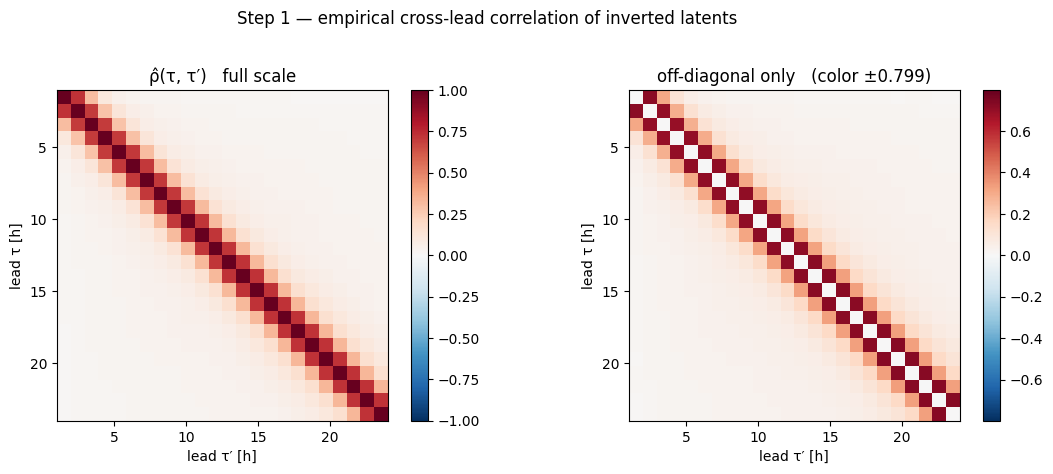

raw per-lead variances : min 0.843, max 0.989  (1 if inversion were exact)
mean |off-diag ρ̂|      : 0.1266
max  |off-diag ρ̂|      : 0.7264
expected SE under H0    : 0.00110


In [18]:
# ── Step 1: cross-lead correlation matrix ───────────────────────────────────
def gram_and_corr(Zin):
    """
    Zin: (n, L, ...) latents → per-sample normalised Grams Gn (n, L, L), the
    mean correlation matrix rho (L, L), and the raw per-lead variances v (L,).
    Centers per lead across samples first.
    """
    # flatten others except num_traj and lead time
    # (387, 24, 2*64*64)
    Xf = Zin.reshape(Zin.shape[0], Zin.shape[1], -1)
    Xf = Xf - Xf.mean(axis=0, keepdims=True)              # remove per-lead mean field
    # It computes the correlation between leads
    # for each n, there is a L*L matrix
    G  = np.einsum("nlx,nmx->nlm", Xf, Xf) / Xf.shape[-1] # (n, L, L) 
    
    # why mean here at first?
    # wipe out the trajectories
    v  = np.diagonal(G.mean(axis=0)).copy()               # raw per-lead variances
    # outer produces a matrix from two vectors
    # outer(v,v) would be the variance of leads over all trajectories
    Gn = G / np.sqrt(np.outer(v, v))                      # normalised per sample

    # Gn (387, 24, 24), Gn.mean (24, 24), v (24, )
    return Gn, Gn.mean(axis=0), v

def collapse_by_lag(Gn):
    """Per-sample mean over each diagonal Δ ⟹ ρ̄(Δ) with an honest sample SE."""
    # Gn (387, 24, 24)
    # L_=24
    n, L_, _ = Gn.shape
    deltas   = np.arange(1, L_)
    rho_bar  = np.empty(L_ - 1)
    # whose se is it computing?
    se_bar   = np.empty(L_ - 1)
    for i, D in enumerate(deltas):
        # what does this mean
        # return the average of diagonal numbers above D line exact diagonal in a trajectory's matrix 
        # mean operates over leads
        
        # it's double average pooling to get correlation only on the dependence of delta
        # 1/(leads-1) \sum_{\delta=1}^{leads-1} cov[x_t, x_{t+delta}] 
        per_sample = np.diagonal(Gn, offset=D, axis1=1, axis2=2).mean(axis=1)  # (n,)
        rho_bar[i] = per_sample.mean()
        se_bar[i]  = per_sample.std(ddof=1) / np.sqrt(n)
    return deltas, rho_bar, se_bar

Gn, rho, var_l = gram_and_corr(Z)

# what does ~ mean?
# well semantically it means off-diagonal
off = rho[~np.eye(L, dtype=bool)]
vmax = max(np.abs(off).max() * 1.1, 0.05)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
im0 = axes[0].imshow(rho, cmap="RdBu_r", vmin=-1, vmax=1, extent=[1, 24, 24, 1])
axes[0].set_title("ρ̂(τ, τ′)   full scale")
im1 = axes[1].imshow(rho - np.eye(L), cmap="RdBu_r", vmin=-vmax, vmax=vmax, extent=[1, 24, 24, 1])
axes[1].set_title(f"off-diagonal only   (color ±{vmax:.3f})")
for ax, im in zip(axes, [im0, im1]):
    ax.set_xlabel("lead τ′ [h]"); ax.set_ylabel("lead τ [h]")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Step 1 — empirical cross-lead correlation of inverted latents", y=1.02)
fig.tight_layout()
plt.show()

print(f"raw per-lead variances : min {var_l.min():.3f}, max {var_l.max():.3f}  (1 if inversion were exact)")
print(f"mean |off-diag ρ̂|      : {np.abs(off).mean():.4f}")
print(f"max  |off-diag ρ̂|      : {np.abs(off).max():.4f}")
print(f"expected SE under H0    : {1/np.sqrt(d)/np.sqrt(N):.5f}")

## Step 2 — test the Thread-3 hypotheses, in order of simplicity

- **(a) Stationarity**: does $\hat\rho(\tau,\tau')$ depend only on $\Delta = |\tau-\tau'|$? Plot $\hat\rho(\tau,\tau+\Delta)$ vs $\tau$ for fixed $\Delta$ — flat lines ⟹ stationary.


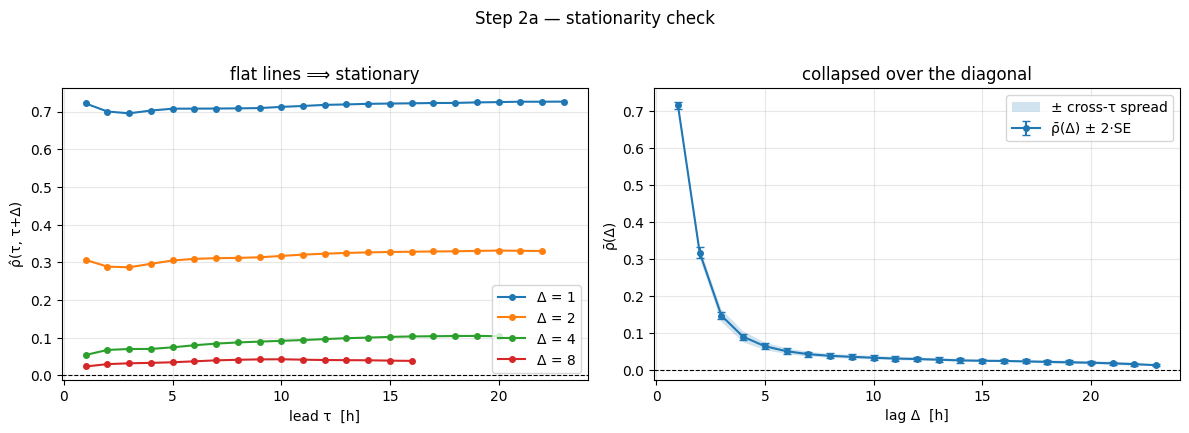

Δ=1:  mean +0.7157   cross-τ std 0.0092   est. SE 0.0049   → consistent with stationary
Δ=2:  mean +0.3171   cross-τ std 0.0138   est. SE 0.0068   → consistent with stationary
Δ=4:  mean +0.0892   cross-τ std 0.0151   est. SE 0.0041   → non-stationary?
Δ=8:  mean +0.0375   cross-τ std 0.0053   est. SE 0.0035   → consistent with stationary


In [19]:
# ── Step 2a: stationarity — ρ̂(τ, τ+Δ) as a function of τ ───────────────────

deltas_show = [1, 2, 4, 8]
deltas, rho_bar, se_bar = collapse_by_lag(Gn)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for D in deltas_show:
    # rho is the covariance matrix pooling over all trajectories
    # diagonal over D means only delta is unchanged, tao changes
    diag_vals = np.diagonal(rho, offset=D)                 # (Leads-Δ,)
    axes[0].plot(leads[:L - D], diag_vals, "o-", ms=4, label=f"Δ = {D}")
axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_xlabel("lead τ  [h]")
axes[0].set_ylabel("ρ̂(τ, τ+Δ)")
axes[0].set_title("flat lines ⟹ stationary")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].errorbar(deltas, rho_bar, yerr=2 * se_bar, fmt="o-", ms=4, capsize=3,
                 label="ρ̄(Δ) ± 2·SE")
# cross-τ spread of the diagonal — big compared to SE ⟹ non-stationarity
spread = np.array([np.diagonal(rho, offset=D).std(ddof=1) if D < L - 1 else 0.0
                   for D in deltas])
axes[1].fill_between(deltas, rho_bar - spread, rho_bar + spread, alpha=0.2,
                     label="± cross-τ spread")
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_xlabel("lag Δ  [h]")
axes[1].set_ylabel("ρ̄(Δ)")
axes[1].set_title("collapsed over the diagonal")
axes[1].legend()
axes[1].grid(alpha=0.3)
fig.suptitle("Step 2a — stationarity check", y=1.02)
fig.tight_layout()
plt.show()

# quantify: for each shown Δ, compare cross-τ spread with the estimation SE
for D in deltas_show:
    dv = np.diagonal(rho, offset=D)
    print(f"Δ={D}:  mean {dv.mean():+.4f}   cross-τ std {dv.std(ddof=1):.4f}   est. SE {se_bar[D-1]:.4f}"
          f"   → {'non-stationary?' if dv.std(ddof=1) > 3 * se_bar[D-1] else 'consistent with stationary'}")

## Conclusion for empirical correlation visualization

Visually, all good. The correlation is stationary over lead time and differs from different $\delta$, and the plot between correlation and $\delta$ looks good as well -- It decays feeling like exponential decay. But the std of correlation cross $\tau$ goes beyond the std from sample itself theoretically, not a big problem I think, I would check again after invert data with more steps.

Visually all good says nothing, let's see in the next section.


- **(b) Decay form**: OU/AR(1) ⟹ $\rho(\Delta)=e^{-r\Delta}$, i.e. $\log\bar\rho$ **linear** in $\Delta$; squared-exponential ⟹ $\log\bar\rho \propto -\Delta^2$ ($ρ(Δ)=e^{−Δ^2/ℓ^2}$). If linear → the Alg.-2 OU family is adequate and its rate is read off the slope by regression (Thread 3's first milestone, no learning machinery). Note the current sampler's `get_latents(α)` is AR(1) with coefficient $\sqrt\alpha$ ⟹ $\rho(\Delta) = \alpha^{\Delta/2}$; for $\alpha=0.5$ that's $r=\ln 2/2 \approx 0.347$ — plotted as reference for what the forecasts currently assume.


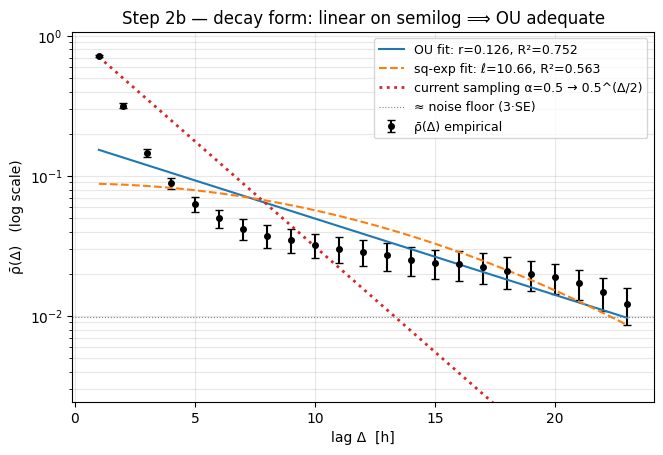

fit over Δ ∈ [1, 23]  (23 lags above noise floor)
OU rate r          : 0.1256  per hour   (R² = 0.7517)
sq-exp lengthscale : 10.663 h            (R² = 0.5631)
⟹ equivalent get_latents α = e^(−2r) = 0.778   (currently sampling with α = 0.5)
⟹ ρ̄(1) demanded = 0.716  vs  α=0.5 assumes 0.707


In [20]:
# ── Step 2b: decay-form test — OU (exponential) vs squared-exponential ──────
# Fit only lags where ρ̄ is clearly above the noise floor (3×SE) AND positive.
mask = (rho_bar > 3 * se_bar) & (rho_bar > 0)
n_fit = mask.sum()

if n_fit < 3:
    print(f"Only {n_fit} lag(s) above the noise floor — the correlation demanded by the")
    print("true dynamics is indistinguishable from ZERO at almost all lags.")
    print("⟹ (near-)independent noise; OU/SE kernel fitting is not meaningful here.")
    print(f"   ρ̄(1) = {rho_bar[0]:+.4f} ± {se_bar[0]:.4f}")
else:
    D_fit, r_fit = deltas[mask], rho_bar[mask]
    log_r = np.log(r_fit)

    # OU / AR(1):        log ρ = a − r·Δ
    # 1 means log_rho = a_0 + a_1 * deltas: it would be a straight line
    ou_coef  = np.polyfit(D_fit, log_r, 1)
    ou_pred  = np.polyval(ou_coef, D_fit)
    # this is used to evaluate the fitting quality
    ou_r2    = 1 - np.sum((log_r - ou_pred)**2) / np.sum((log_r - log_r.mean())**2)
    # what does this mean
    rate     = -ou_coef[0]

    # squared-exponential: log ρ = b − Δ²/(2ℓ²)   (linear in Δ²)
    # think about why I need to fix the square
    # reference in case that what if it's not linear
    se_coef  = np.polyfit(D_fit**2, log_r, 1)
    se_pred  = np.polyval(se_coef, D_fit**2)
    se_r2    = 1 - np.sum((log_r - se_pred)**2) / np.sum((log_r - log_r.mean())**2)
    ell      = np.sqrt(-1 / (2 * se_coef[0])) if se_coef[0] < 0 else np.inf
    # NOTE: x-axis is linear and y-axis is log, which means it is used to detect exponential decay
    plt.figure(figsize=(7.5, 4.8))
    plt.errorbar(deltas, rho_bar, yerr=2 * se_bar, fmt="ko", ms=4, capsize=3, label="ρ̄(Δ) empirical")
    Dg = np.linspace(1, deltas[mask].max(), 100)
    plt.semilogy(Dg, np.exp(np.polyval(ou_coef, Dg)), "-",  label=f"OU fit: r={rate:.3f}, R²={ou_r2:.3f}")
    plt.semilogy(Dg, np.exp(np.polyval(se_coef, Dg**2)), "--", label=f"sq-exp fit: ℓ={ell:.2f}, R²={se_r2:.3f}")
    plt.semilogy(Dg, 0.5**(Dg / 2), ":", color="tab:red", lw=2,
                 label="current sampling α=0.5 → 0.5^(Δ/2)")
    plt.axhline(3 * se_bar.mean(), color="gray", lw=0.8, ls=":", label="≈ noise floor (3·SE)")
    plt.ylim(bottom=max(1e-4, rho_bar[mask].min() / 5))
    plt.xlabel("lag Δ  [h]"); plt.ylabel("ρ̄(Δ)   (log scale)")
    plt.title("Step 2b — decay form: linear on semilog ⟹ OU adequate")
    plt.legend(fontsize=9); plt.grid(alpha=0.3, which="both")
    plt.show()

    # AR(1) in get_latents has coefficient sqrt(α): ρ(Δ)=α^{Δ/2} ⟹ α = e^{−2r}
    alpha_hat = np.exp(-2 * rate)
    print(f"fit over Δ ∈ [1, {D_fit.max()}]  ({n_fit} lags above noise floor)")
    print(f"OU rate r          : {rate:.4f}  per hour   (R² = {ou_r2:.4f})")
    print(f"sq-exp lengthscale : {ell:.3f} h            (R² = {se_r2:.4f})")
    print(f"⟹ equivalent get_latents α = e^(−2r) = {alpha_hat:.3f}   (currently sampling with α = 0.5)")
    print(f"⟹ ρ̄(1) demanded = {rho_bar[0]:.3f}  vs  α=0.5 assumes {0.5**0.5:.3f}")

This plot says the empirical process decays neither exponentially or squared-exponentially

- **(c) $x_0$-dependence**: bin $\bar\rho(\Delta)$ by anchor enstrophy ($\overline{\theta^2}$ of $x_0$). Dependence ⟹ the conditional-noise-model question is real; independence ⟹ parametric families suffice and the neural-net step can be skipped.

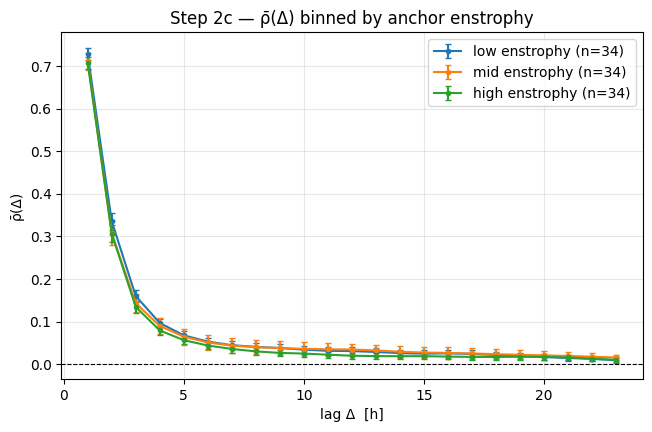

Pearson corr( anchor enstrophy , per-sample ρ(Δ=1) ) = -0.170   (p = 0.09)
⟹ no significant x₀-dependence — parametric (unconditional) kernels suffice.


In [21]:
# ── Step 2c: does the demanded correlation depend on the anchor x₀? ─────────
# Bin samples by anchor enstrophy (mean θ² of x₀, model units) into terciles
# and re-estimate ρ̄(Δ) per bin. Also a direct test: Pearson correlation between
# per-sample lag-1 latent correlation and anchor enstrophy.
ens_anchor = (anchors ** 2).mean(axis=(1, 2, 3))                    # (N,)
edges      = np.quantile(ens_anchor, [0, 1/3, 2/3, 1])
labels     = ["low", "mid", "high"]

plt.figure(figsize=(7.5, 4.5))
for lo, hi, lab in zip(edges[:-1], edges[1:], labels):
    sel = (ens_anchor >= lo) & (ens_anchor <= hi)
    D_g, rb_g, se_g = collapse_by_lag(Gn[sel])
    plt.errorbar(D_g, rb_g, yerr=2 * se_g, fmt="o-", ms=3, capsize=2,
                 label=f"{lab} enstrophy (n={sel.sum()})")
plt.axhline(0, color="k", lw=0.8, ls="--")
plt.xlabel("lag Δ  [h]"); plt.ylabel("ρ̄(Δ)")
plt.title("Step 2c — ρ̄(Δ) binned by anchor enstrophy")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# direct per-sample test at Δ=1
lag1_per_sample = np.diagonal(Gn, offset=1, axis1=1, axis2=2).mean(axis=1)   # (N,)
r_p, p_val = stats.pearsonr(ens_anchor, lag1_per_sample)
print(f"Pearson corr( anchor enstrophy , per-sample ρ(Δ=1) ) = {r_p:+.3f}   (p = {p_val:.2g})")
print("⟹ " + ("x₀-dependence is REAL — the conditional-noise-model question is live."
              if p_val < 0.05 else
              "no significant x₀-dependence — parametric (unconditional) kernels suffice."))

## Step 3 — identifiability control (predict + invert data only)

The closed loop: the forecasts in `data/predit_alpha=0.5` were generated with **known** latent correlation — `get_latents(α=0.5)` is AR(1) with coefficient $\sqrt{0.5}$, so within each 24-lead window $\rho(\Delta) = 0.5^{\Delta/2} = e^{-0.347\Delta}$. Invert those forecasts back through the sampler and re-estimate $\bar\rho(\Delta)$: **if the known rate isn't recovered, estimates from real data (Steps 1–2) mean nothing.**

Implementation notes:
- Only window 0 of each sample is used — its anchor is not stored in the `.npy`, but `forecast()` built its eval dataset with `seed=42, eval_traj_num=100, shuffle=False`, so rebuilding that dataset reproduces the (traj, anchor) pairs; an assertion cross-checks the stored `truth` against the dataset frames before trusting it.
- Since these windows are *model samples*, the inversion is near-exact (no model-error dumping, unlike real data) — their marginal std is also printed as a contrast to Step 0.
- Compute: `N_SAMPLES_S3 × N_ENS_S3` windows × 24 fields × 100 Euler steps — seconds on GPU, ~minutes on CPU; shrink the two knobs if needed.

In [22]:
# ── Step 3: invert the α=0.5 forecasts (known correlation) ──────────────────
from Condition_model.dataset import SQGLeadTimeDataset
from Condition_model.cond_sampler import CondSampler
from Condition_model.train import SAVE_PATH

RUN_STEP3    = True
N_SAMPLES_S3 = 12      # predict files to invert
N_ENS_S3     = 8       # ensemble members per file  → 96 windows total

if RUN_STEP3:
    pred_dir = DATA_PATH / 'predit_alpha=0.5'

    # rebuild the SAME eval dataset forecast() used, to recover the anchors
    ds_eval = SQGLeadTimeDataset(
        DATA_500, split='val', random_lead_time=False,
        eval_traj_num=100, max_lead=24, max_frames=100, seed=42,
    )
    device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    sampler = CondSampler(model_path=SAVE_PATH, device=device, steps=100)
    lt_base = torch.arange(1, 25, dtype=torch.float32) / 24.0     # leads 1..24, normalised

    Z_rec = []
    for i in range(N_SAMPLES_S3):
        predicts = np.load(pred_dir / f"sample{i:02d}_predicts.npy")   # (n_ar+1, 24, ens, 2, 64, 64)
        truth    = np.load(pred_dir / f"sample{i:02d}_truth.npy")
        tj, at   = ds_eval._eval_points[i]
        anchor   = ds_eval.data[tj][at]                                # (2, 64, 64)

        # cross-check: stored truth for window 0 must equal dataset frames anchor+1..anchor+24
        assert np.allclose(truth[0], ds_eval.data[tj][at + 1: at + 25].numpy(), atol=1e-5), \
            f"sample{i:02d}: eval-point reconstruction failed (seed / eval_traj_num mismatch?)"

        # window 0, first N_ENS_S3 members → member-major batch, leads in order
        win = torch.tensor(predicts[0, :, :N_ENS_S3])                  # (24, ens, 2, 64, 64)
        win = win.permute(1, 0, 2, 3, 4).reshape(N_ENS_S3 * 24, 2, 64, 64)
        x_t = anchor.unsqueeze(0).repeat(N_ENS_S3 * 24, 1, 1, 1)
        lt  = lt_base.repeat(N_ENS_S3)                                 # matches forecast()'s layout

        z_hat = sampler.sample(z0=win, x_t=x_t, lead_times=lt, invert=True)
        Z_rec.append(z_hat.reshape(N_ENS_S3, 24, 2, 64, 64).numpy())
        print(f"sample{i:02d}: inverted {N_ENS_S3} windows   (traj {tj}, anchor {at})")

    Z_rec = np.concatenate(Z_rec)          # (N_SAMPLES_S3·N_ENS_S3, 24, 2, 64, 64)
    print(f"\nZ_rec: {Z_rec.shape}   mean = {Z_rec.mean():+.4f}, std = {Z_rec.std():.4f}"
          f"   (model samples ⟹ should be very close to 0, 1)")

sample00: inverted 8 windows   (traj 8, anchor 63)
sample01: inverted 8 windows   (traj 77, anchor 15)
sample02: inverted 8 windows   (traj 65, anchor 61)
sample03: inverted 8 windows   (traj 43, anchor 0)
sample04: inverted 8 windows   (traj 43, anchor 60)
sample05: inverted 8 windows   (traj 85, anchor 59)
sample06: inverted 8 windows   (traj 8, anchor 59)
sample07: inverted 8 windows   (traj 69, anchor 50)
sample08: inverted 8 windows   (traj 20, anchor 35)
sample09: inverted 8 windows   (traj 9, anchor 53)
sample10: inverted 8 windows   (traj 52, anchor 21)
sample11: inverted 8 windows   (traj 97, anchor 59)

Z_rec: (96, 24, 2, 64, 64)   mean = -0.0014, std = 0.9532   (model samples ⟹ should be very close to 0, 1)


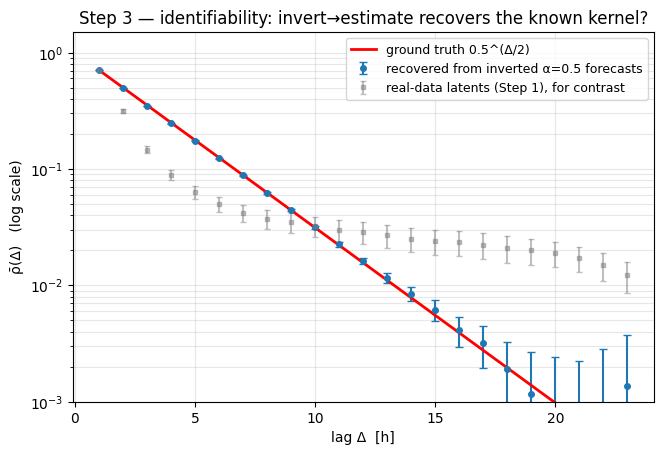

recovered rate r̂ = 0.3384   vs   theoretical ln(2)/2 = 0.3466
recovered α̂ = e^(−2r̂) = 0.508   vs   true α = 0.5
Δ=1:  recovered 0.7062 ± 0.0007   theory 0.7071   (-1.3 SE)
Δ=2:  recovered 0.4955 ± 0.0007   theory 0.5000   (-6.9 SE)
Δ=4:  recovered 0.2467 ± 0.0005   theory 0.2500   (-6.4 SE)
Δ=8:  recovered 0.0626 ± 0.0005   theory 0.0625   (+0.2 SE)

pipeline is identifiable if the recovered points track the red line within a few SE;
a systematic shortfall = attenuation bias of invert→estimate — correct Step-1/2 readings by it.


In [23]:
# ── Step 3 (cont.): does the pipeline recover the known correlation? ────────
# Separate cell so the expensive inversion above isn't re-run while tweaking plots.
if RUN_STEP3:
    Gn_rec, rho_rec, var_rec = gram_and_corr(Z_rec)
    D_rec, rb_rec, se_rec    = collapse_by_lag(Gn_rec)

    # theoretical target: AR(1) with coefficient sqrt(0.5) ⟹ ρ(Δ) = 0.5^(Δ/2)
    rho_theory = 0.5 ** (D_rec / 2)

    plt.figure(figsize=(7.5, 4.8))
    plt.errorbar(D_rec, rb_rec, yerr=2 * se_rec, fmt="o", ms=4, capsize=3,
                 label="recovered from inverted α=0.5 forecasts")
    plt.semilogy(D_rec, rho_theory, "r-", lw=2, label="ground truth 0.5^(Δ/2)")
    plt.errorbar(deltas, rho_bar, yerr=2 * se_bar, fmt="s", ms=3, capsize=2,
                 alpha=0.5, color="gray", label="real-data latents (Step 1), for contrast")
    plt.ylim(1e-3, 1.5)
    plt.xlabel("lag Δ  [h]"); plt.ylabel("ρ̄(Δ)   (log scale)")
    plt.title("Step 3 — identifiability: invert→estimate recovers the known kernel?")
    plt.legend(fontsize=9); plt.grid(alpha=0.3, which="both")
    plt.show()

    # recovered rate via regression on the lags above the noise floor
    m_rec = (rb_rec > 3 * se_rec) & (rb_rec > 0)
    if m_rec.sum() >= 3:
        rate_rec = -np.polyfit(D_rec[m_rec], np.log(rb_rec[m_rec]), 1)[0]
        print(f"recovered rate r̂ = {rate_rec:.4f}   vs   theoretical ln(2)/2 = {np.log(2)/2:.4f}")
        print(f"recovered α̂ = e^(−2r̂) = {np.exp(-2 * rate_rec):.3f}   vs   true α = 0.5")
    # pointwise check at small lags, where the signal is strongest
    for D in [1, 2, 4, 8]:
        i = D - 1
        n_se = (rb_rec[i] - rho_theory[i]) / se_rec[i]
        print(f"Δ={D}:  recovered {rb_rec[i]:.4f} ± {se_rec[i]:.4f}   theory {rho_theory[i]:.4f}   ({n_se:+.1f} SE)")
    print("\npipeline is identifiable if the recovered points track the red line within a few SE;")
    print("a systematic shortfall = attenuation bias of invert→estimate — correct Step-1/2 readings by it.")

## Reading the results — decision checklist

| Figure | Question | If yes | If no |
|---|---|---|---|
| 0a/0b | marginals ≈ N(0,1)? | correlation estimates trustworthy | model error contaminates latents — interpret Steps 1–2 qualitatively only |
| 0c | spectrum flat? | inversion clean | the non-flat wavenumbers localise *where* the drift is wrong (free diagnostic, feeds Thread 1) |
| 3 | known α=0.5 recovered? | **pipeline identifiable — Steps 1–2 are meaningful** | fix invert→estimate before interpreting anything |
| 2a | ρ̂ stationary in τ? | a single kernel ρ(Δ) suffices | need σ(t) / lead-dependent kernel |
| 2b | log ρ̄ linear in Δ? | **OU family adequate — read the rate off the slope; Thread 3's first milestone done with no learning machinery** | smoother kernel required (e.g. squared-exponential, cf. PYoCo / How-I-Warped-Your-Noise) |
| 2c | ρ̄ depends on x₀? | conditional noise model is a real research question | parametric kernels suffice, skip the neural-net step |

**Next (Thread 1, used the right way round):** once a kernel is fitted here, regenerate forecasts sampling with it and use residual spectra ΔX as the *validation criterion* — not open-ended exploration. Expected per CEWF Fig. 5: frozen noise (α→1) suppresses high-frequency ΔX content; the fitted kernel should restore it to match data. Requires a new `forecast()` run with the fitted kernel plugged into `get_latents` — out of scope for this notebook's data.